<a href="https://colab.research.google.com/github/salmakhale/ML-Data-Analysis/blob/main/House_Rent_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read Data

In [ ]:
df = pd.read_csv('House_Rent_Dataset.csv')

In [ ]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,5/18/2022,2,10000.0,1100.0,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,5/13/2022,2,20000.0,NaN,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
2,5/16/2022,2,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,7/4/2022,2,10000.0,NaN,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,5/9/2022,2,7500.0,850.0,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner


In [ ]:
df.shape

(4746, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Posted On          4746 non-null   object 
 1   BHK                4746 non-null   int64  
 2   Rent               4741 non-null   float64
 3   Size               4738 non-null   float64
 4   Floor              4746 non-null   object 
 5   Area Type          4739 non-null   object 
 6   Area Locality      4746 non-null   object 
 7   City               4746 non-null   object 
 8   Furnishing Status  4746 non-null   object 
 9   Tenant Preferred   4746 non-null   object 
 10  Bathroom           4742 non-null   float64
 11  Point of Contact   4746 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 445.1+ KB


In [ ]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.741000e+03,4738.000000,4742.000000
mean,2.083860,3.502340e+04,967.936049,1.965837
std,0.832256,7.814214e+04,634.562635,0.884904
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [ ]:
df.drop(['Posted On'],axis =1 ,inplace=True)

# Check null value

In [ ]:
df.isnull().sum().sort_values()

BHK                  0
Floor                0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Point of Contact     0
Bathroom             4
Rent                 5
Area Type            7
Size                 8
dtype: int64

<Axes: >

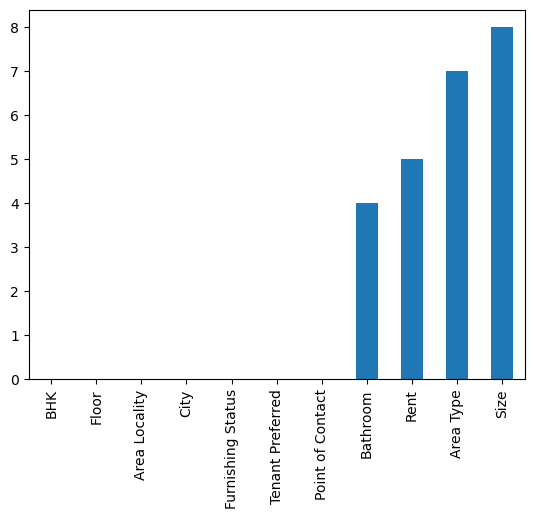

In [ ]:
df.isnull().sum().sort_values().plot(kind='bar')

In [ ]:
df.shape

(4746, 11)

In [ ]:
df.Bathroom.head()

0    2.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: Bathroom, dtype: float64

In [ ]:
df.Bathroom.unique()

array([ 2.,  1., nan,  3.,  5.,  4.,  6.,  7., 10.])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   BHK                4746 non-null   int64  
 1   Rent               4741 non-null   float64
 2   Size               4738 non-null   float64
 3   Floor              4746 non-null   object 
 4   Area Type          4739 non-null   object 
 5   Area Locality      4746 non-null   object 
 6   City               4746 non-null   object 
 7   Furnishing Status  4746 non-null   object 
 8   Tenant Preferred   4746 non-null   object 
 9   Bathroom           4742 non-null   float64
 10  Point of Contact   4746 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 408.0+ KB


In [ ]:
from sklearn.impute import SimpleImputer


In [ ]:
impute = SimpleImputer(missing_values=np.nan,
    strategy='median')

In [ ]:
df['Bathroom'] = impute.fit_transform(df[['Bathroom']])

In [ ]:
impute = SimpleImputer(missing_values=np.nan,
    strategy='mean')
df['Size'] = impute.fit_transform(df[['Size']])

In [ ]:
df.isnull().sum()

BHK                  0
Rent                 5
Size                 0
Floor                0
Area Type            7
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [ ]:
impute = SimpleImputer(missing_values=np.nan,
    strategy='most_frequent')
impute.fit(df[['Area Type']])

SimpleImputer(strategy='most_frequent')

In [ ]:
df['Area Type'] =pd.DataFrame(impute.transform(df[['Area Type']]))

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum().sort_values().sum()

0

In [ ]:
df.duplicated().sum()

8

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.head()

,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000.0,1100.000000,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2,20000.0,967.936049,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
2,2,17000.0,1000.000000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2,10000.0,967.936049,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,2,7500.0,850.000000,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner


In [ ]:
cols = list(df.nunique().sort_values().index[:7])
cols

['Area Type',
 'Furnishing Status',
 'Tenant Preferred',
 'Point of Contact',
 'BHK',
 'City',
 'Bathroom']

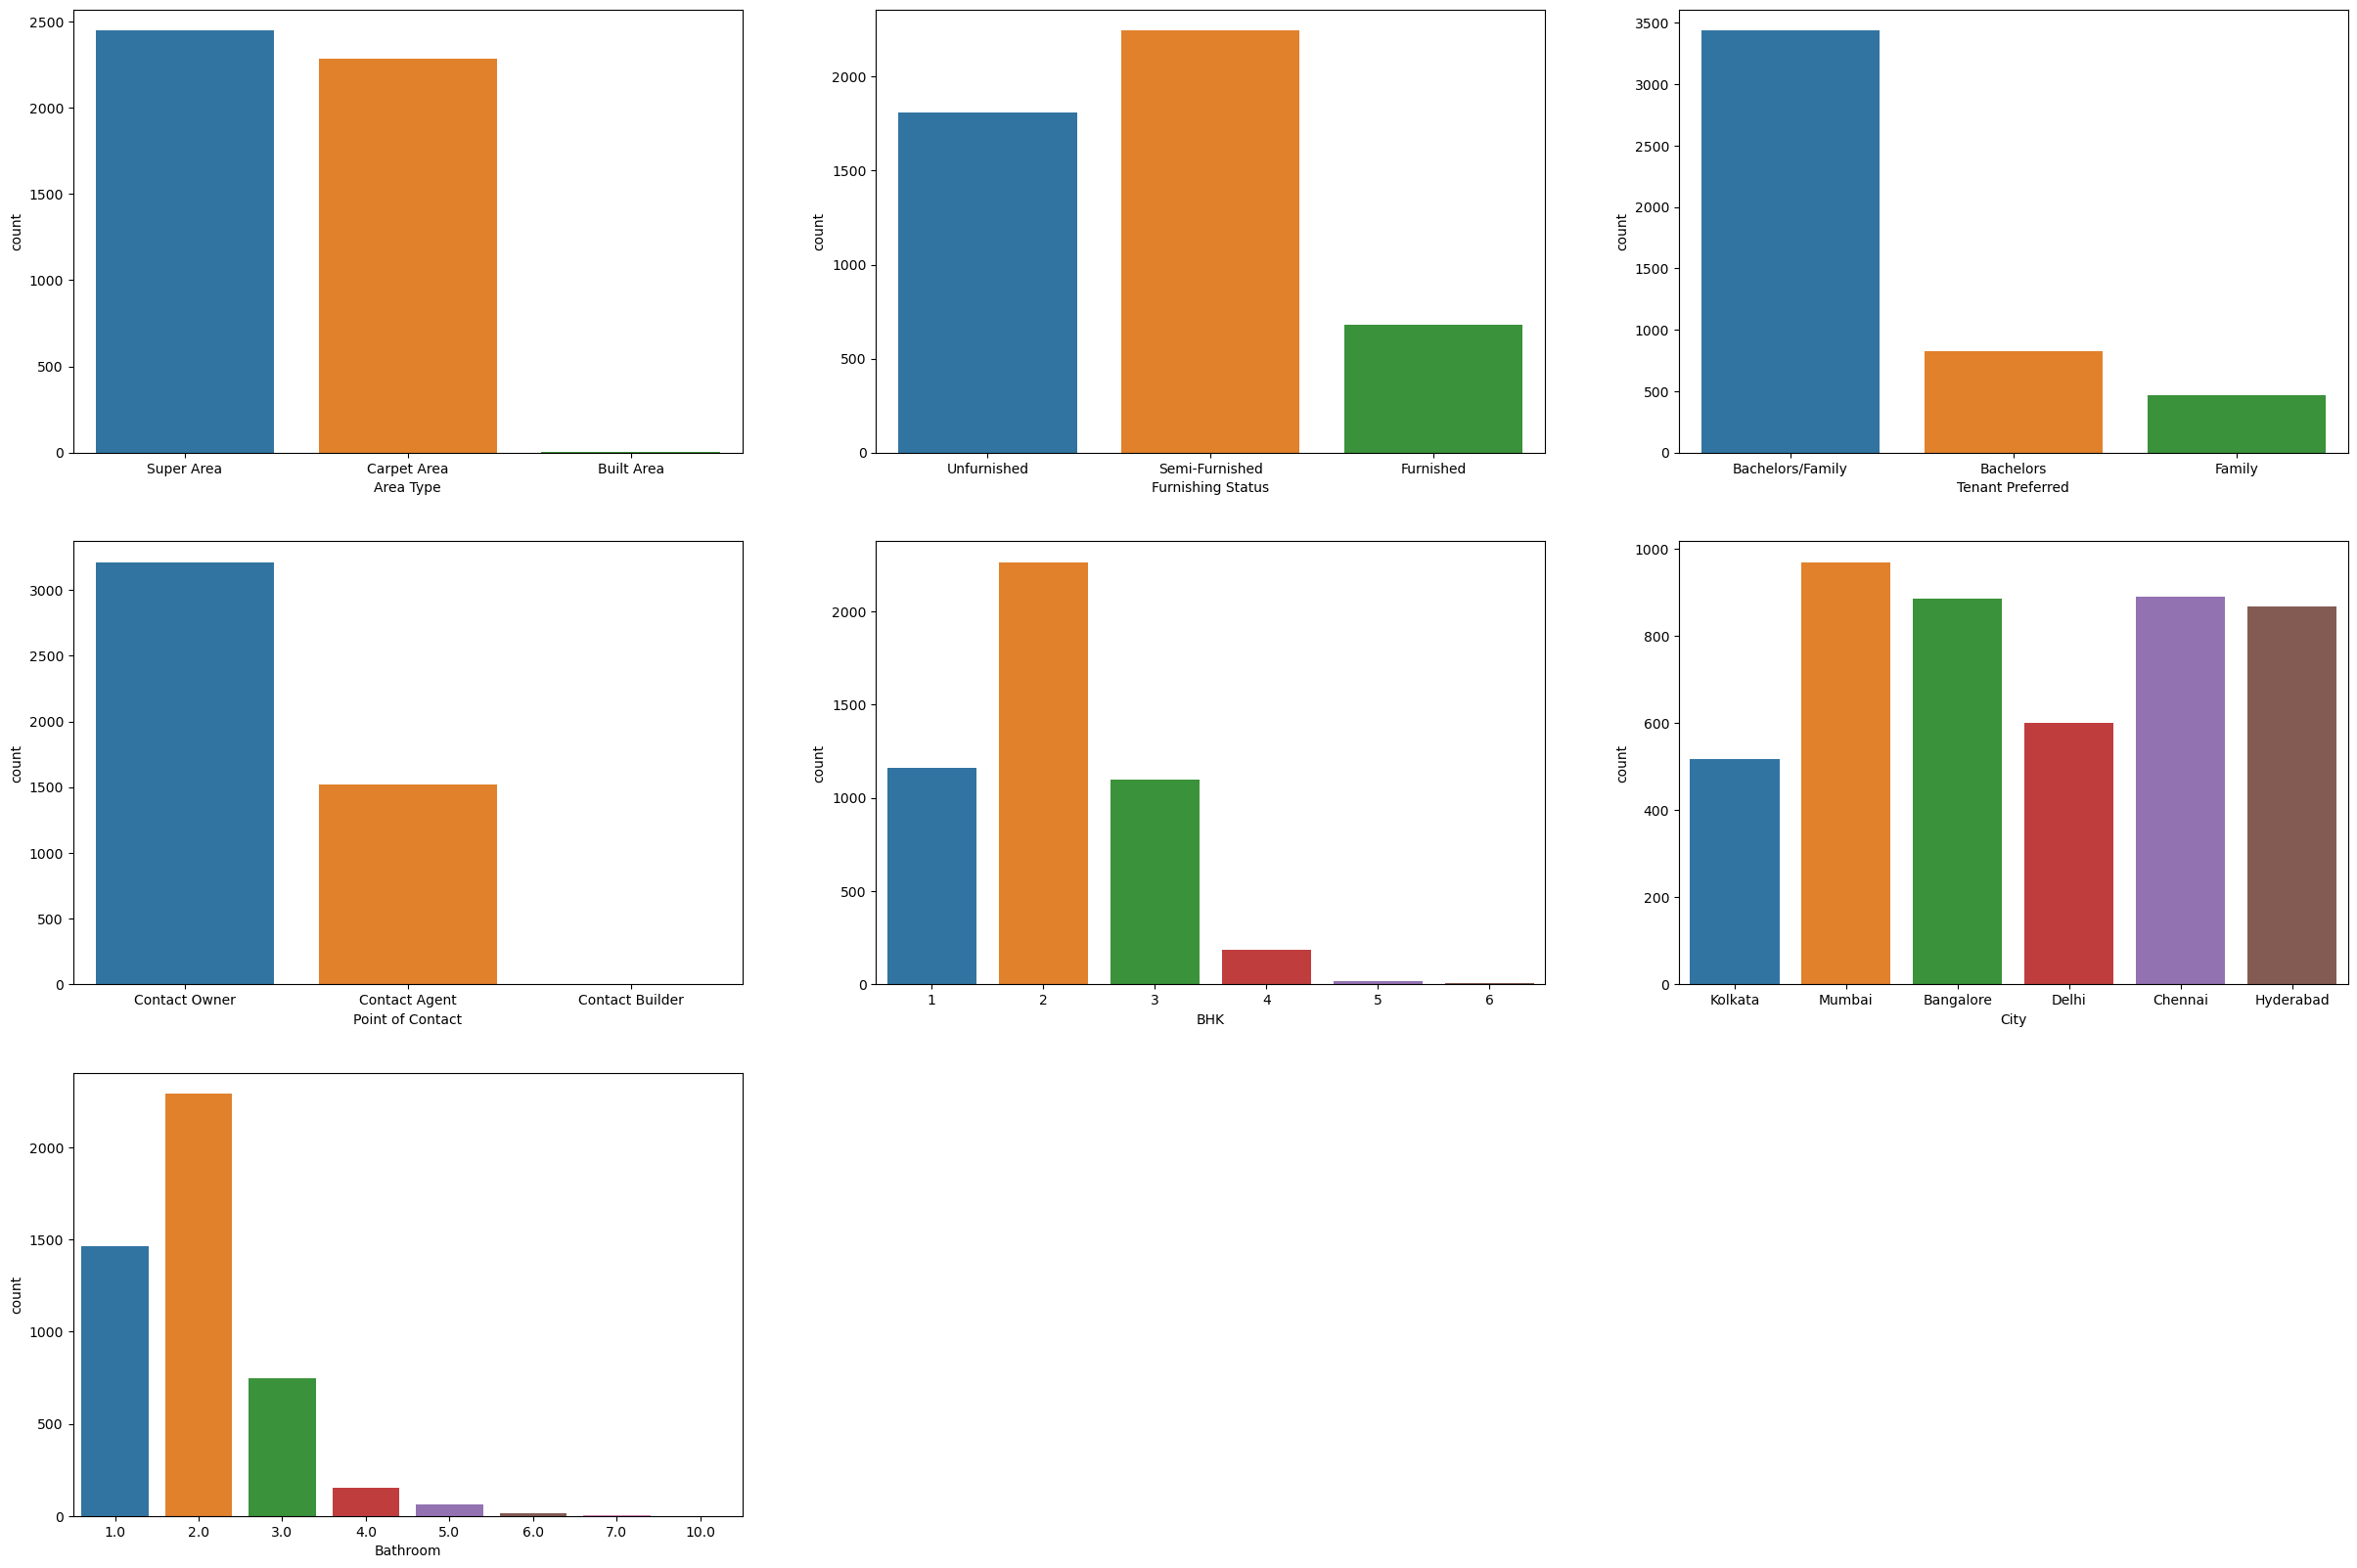

In [ ]:
plt.figure(figsize=(30,20))
for n , col in enumerate(cols) :
    plt.subplot(3,3,n+1)
    sns.countplot(data=df,x=col)


In [ ]:
cols

['Area Type',
 'Furnishing Status',
 'Tenant Preferred',
 'Point of Contact',
 'BHK',
 'City',
 'Bathroom']

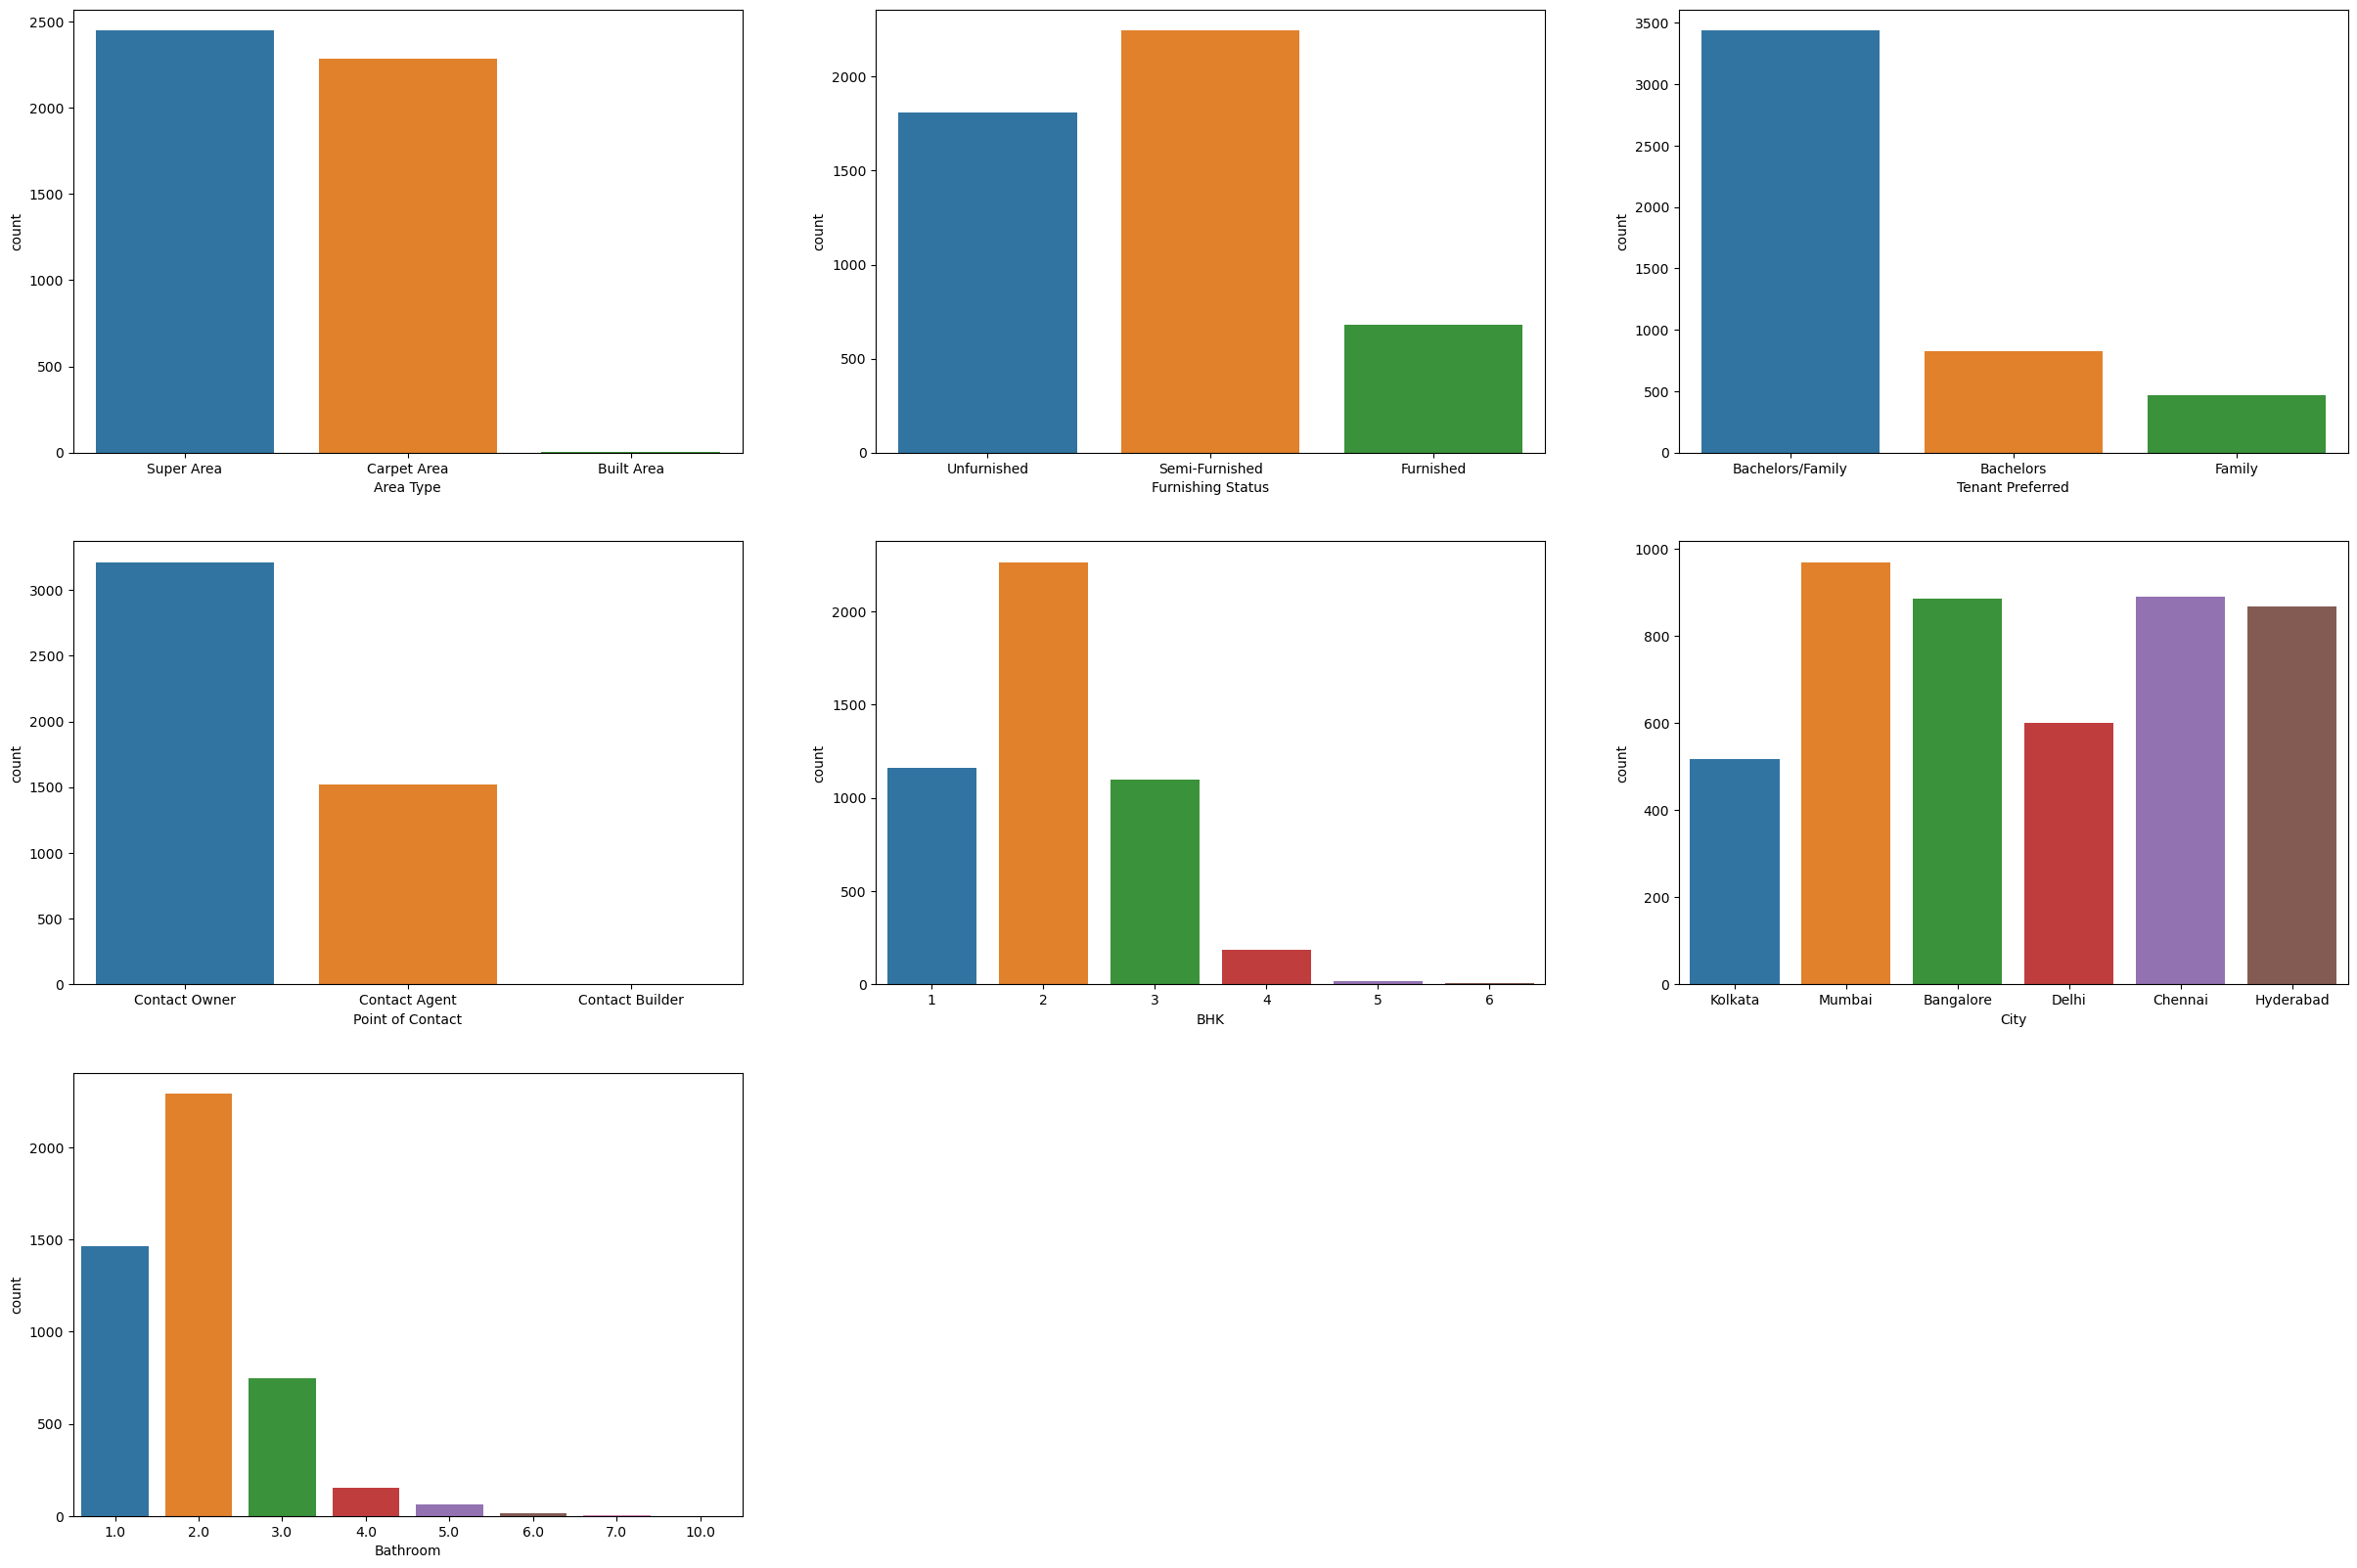

In [ ]:
plt.figure(figsize=(30,20))

for n , k in enumerate(cols) :
    plt.subplot(3,3,n+1)
    sns.countplot(data=df,x=k)
    #plt.show()


In [ ]:
"""
for col in cols :
    plt.figure(figsize=(30,20))
    print(col)
    for n , k in enumerate(cols) :
        plt.subplot(3,3,n+1)
        sns.countplot(data=df,x=col,hue=k)
    plt.show()
    """

'\nfor col in cols :\n    plt.figure(figsize=(30,20))\n    print(col)\n    for n , k in enumerate(cols) :\n        plt.subplot(3,3,n+1)\n        sns.countplot(data=df,x=col,hue=k)\n    plt.show()\n    '

<Axes: xlabel='Area Type', ylabel='count'>

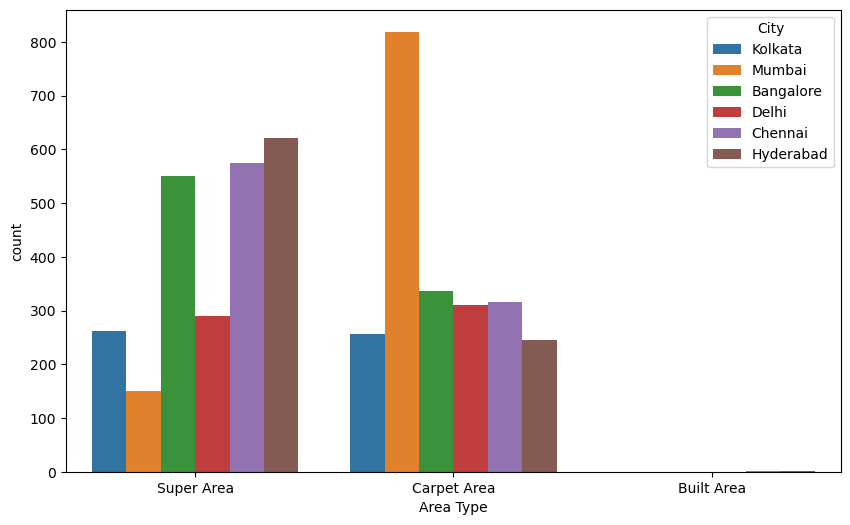

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Area Type',hue='City')

In [ ]:
df.columns

Index(['BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Bathroom',
       'Point of Contact'],
      dtype='object')

<Axes: xlabel='BHK', ylabel='count'>

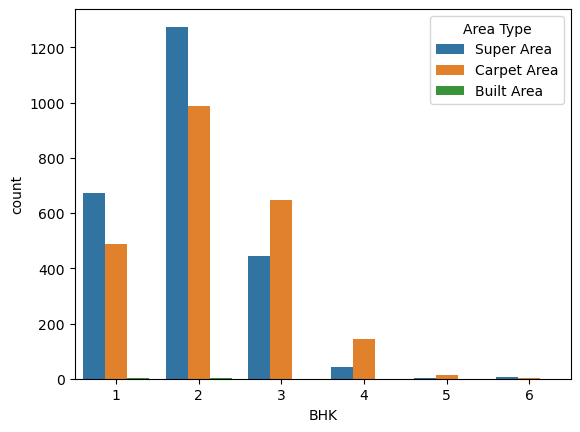

In [ ]:
sns.countplot(data=df,x='BHK',hue='Area Type')

In [ ]:
df['Bathroom'] = df['Bathroom'].astype(str)

<Axes: xlabel='BHK', ylabel='Size'>

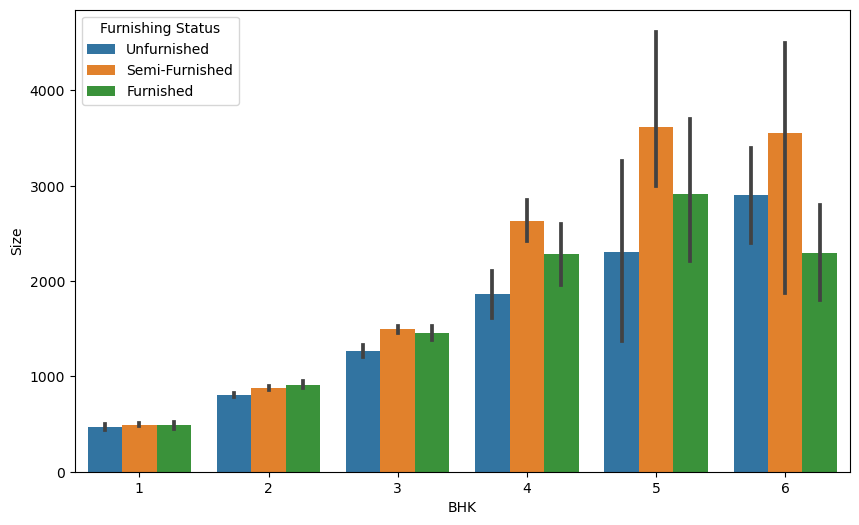

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x ='BHK',y='Size',hue='Furnishing Status')

<Axes: xlabel='BHK', ylabel='Rent'>

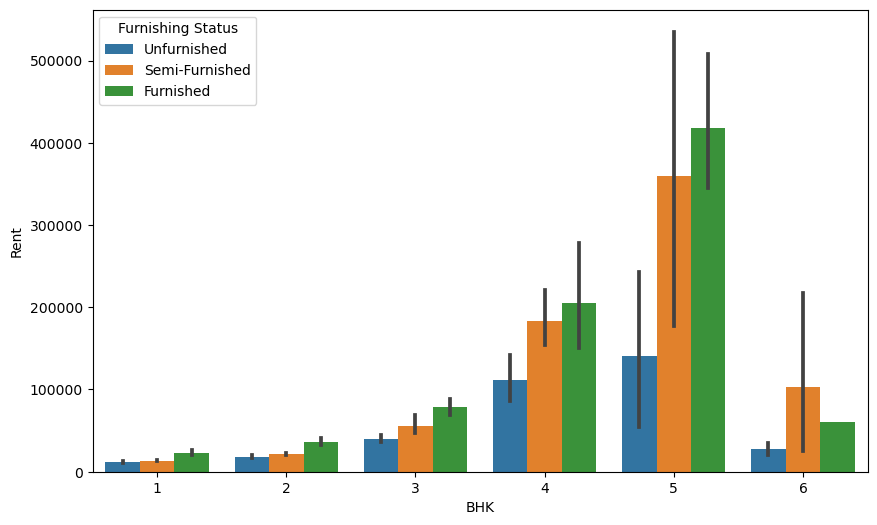

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x ='BHK',y='Rent',hue='Furnishing Status')

<Axes: xlabel='Bathroom', ylabel='BHK'>

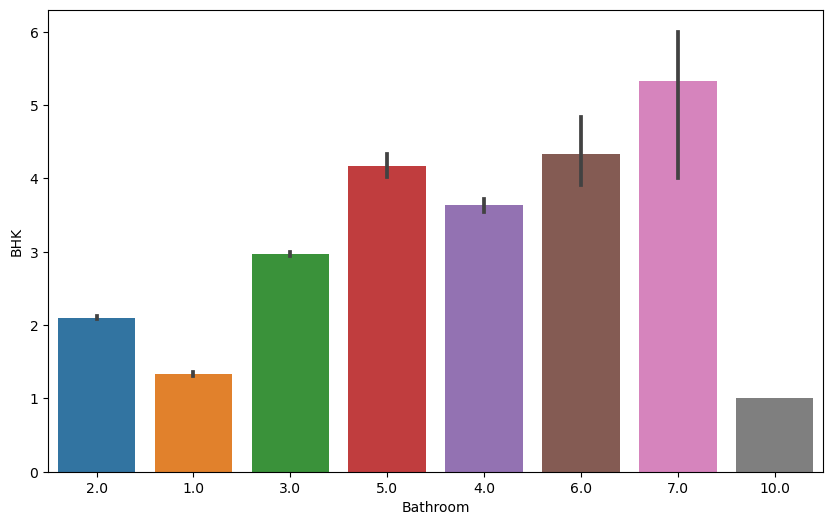

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x ='Bathroom',y='BHK',)

<Axes: xlabel='BHK', ylabel='Size'>

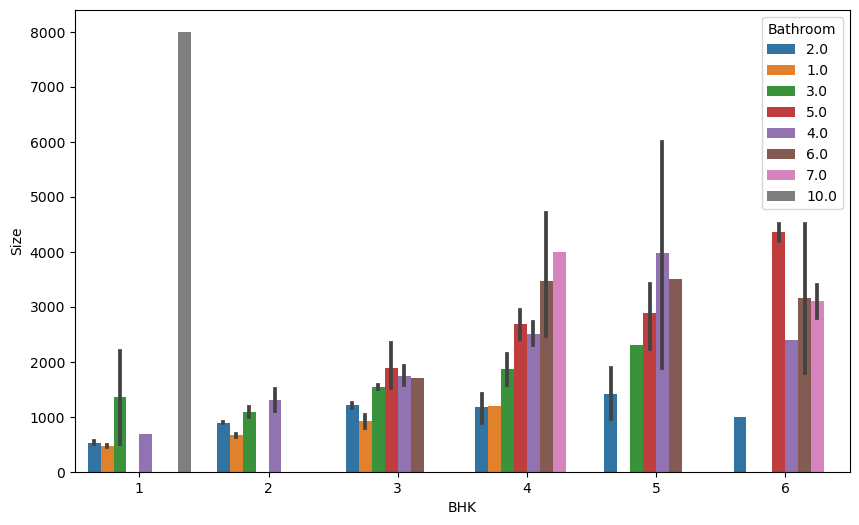

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x ='BHK',y='Size',hue='Bathroom')

C:\Users\Nvidia\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Size', ylabel='Count'>

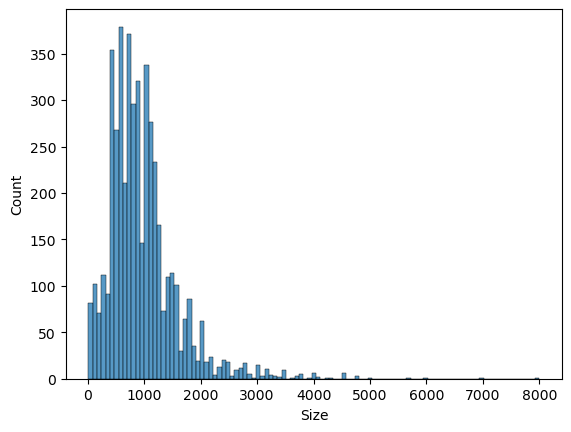

In [ ]:
sns.histplot(data=df,x='Size')

C:\Users\Nvidia\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Rent', ylabel='Count'>

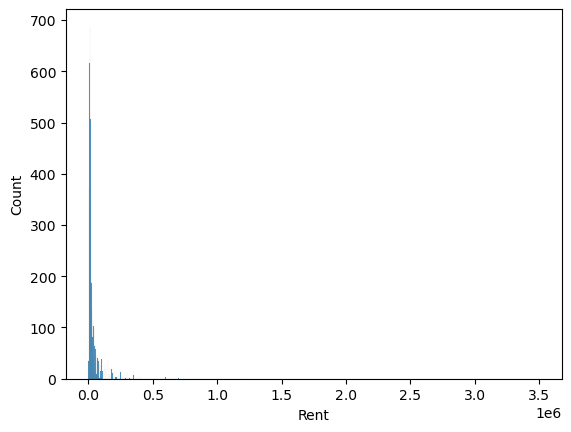

In [ ]:
sns.histplot(data=df,x='Rent')

<Axes: xlabel='Size', ylabel='Rent'>

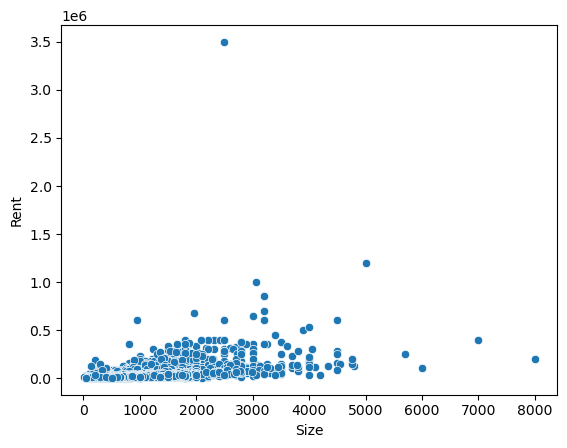

In [ ]:
sns.scatterplot(data=df,x='Size',y='Rent')

<Axes: xlabel='Size', ylabel='Rent'>

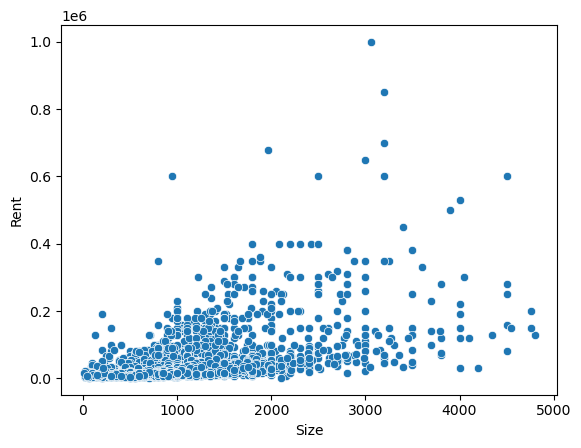

In [ ]:
sns.scatterplot(data=df,x=df[df['Size']<5000]['Size'],y=df[df['Rent']<1500000]['Rent'])

<Axes: >

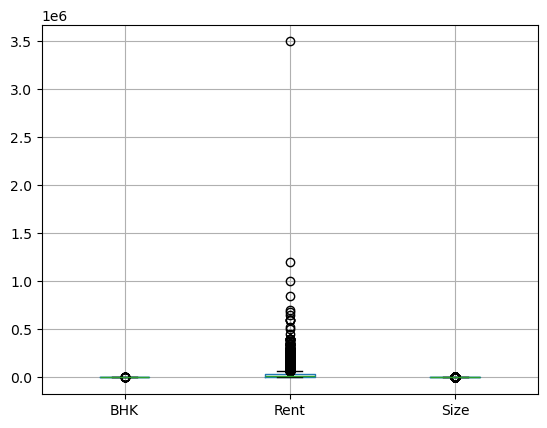

In [ ]:
df.boxplot()

In [ ]:
df=df[df['Size']<5000]
df=df[df['Rent']<1500000]

In [ ]:
df.shape

(4727, 11)

In [ ]:
df['Bathroom'] = df['Bathroom'].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4727 entries, 0 to 4745
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   BHK                4727 non-null   int64  
 1   Rent               4727 non-null   float64
 2   Size               4727 non-null   float64
 3   Floor              4727 non-null   object 
 4   Area Type          4727 non-null   object 
 5   Area Locality      4727 non-null   object 
 6   City               4727 non-null   object 
 7   Furnishing Status  4727 non-null   object 
 8   Tenant Preferred   4727 non-null   object 
 9   Bathroom           4727 non-null   float64
 10  Point of Contact   4727 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 443.2+ KB


# Encoding

In [ ]:
cols=df.select_dtypes('object')

In [ ]:
cols.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4727 entries, 0 to 4745
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Floor              4727 non-null   object
 1   Area Type          4727 non-null   object
 2   Area Locality      4727 non-null   object
 3   City               4727 non-null   object
 4   Furnishing Status  4727 non-null   object
 5   Tenant Preferred   4727 non-null   object
 6   Point of Contact   4727 non-null   object
dtypes: object(7)
memory usage: 295.4+ KB


In [ ]:
cols.nunique()

Floor                 479
Area Type               3
Area Locality        2233
City                    6
Furnishing Status       3
Tenant Preferred        3
Point of Contact        3
dtype: int64

In [ ]:
df

,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000.0,1100.000000,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2,20000.0,967.936049,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
2,2,17000.0,1000.000000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2,10000.0,967.936049,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,2,7500.0,850.000000,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner
...,...,...,...,...,...,...,...,...,...,...,...
4741,2,15000.0,1000.000000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2.0,Contact Owner
4742,3,29000.0,2000.000000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3.0,Contact Owner
4743,3,35000.0,1750.000000,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3.0,Contact Agent
4744,3,45000.0,1500.000000,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2.0,Contact Agent


In [ ]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [ ]:
for c in ['Floor','Area Locality','City']:
    lb = LabelEncoder()
    df[c] = lb.fit_transform(df[c])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4727 entries, 0 to 4745
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   BHK                4727 non-null   int64  
 1   Rent               4727 non-null   float64
 2   Size               4727 non-null   float64
 3   Floor              4727 non-null   int32  
 4   Area Type          4727 non-null   object 
 5   Area Locality      4727 non-null   int32  
 6   City               4727 non-null   int32  
 7   Furnishing Status  4727 non-null   object 
 8   Tenant Preferred   4727 non-null   object 
 9   Bathroom           4727 non-null   float64
 10  Point of Contact   4727 non-null   object 
dtypes: float64(3), int32(3), int64(1), object(4)
memory usage: 387.8+ KB


In [ ]:
cols=df.select_dtypes('object')
type(cols)

pandas.core.frame.DataFrame

In [ ]:
cols.columns

Index(['Area Type', 'Furnishing Status', 'Tenant Preferred',
       'Point of Contact'],
      dtype='object')

In [ ]:
'N_'+str(len(df.columns))

'N_11'

In [ ]:
df.head()

,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000.0,1100.000000,454,Super Area,220,4,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2,20000.0,967.936049,14,Super Area,1525,4,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
2,2,17000.0,1000.000000,14,Super Area,1758,4,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2,10000.0,967.936049,10,Super Area,525,4,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,2,7500.0,850.000000,10,Carpet Area,1888,4,Unfurnished,Bachelors,1.0,Contact Owner


In [ ]:
for c in list(cols.columns) :
    print(c)
    onehotencoder=OneHotEncoder()
    swap = onehotencoder.fit_transform(np.array(df[c]).reshape(-1,1)).toarray()
    for i in range(swap.shape[1]):
        df['N_'+str(len(df.columns))] = swap[:,i]

Area Type
Furnishing Status
Tenant Preferred
Point of Contact


In [ ]:
df.drop(list(cols.columns),axis =1,inplace = True)

In [ ]:
df.head()

,BHK,Rent,Size,Floor,Area Locality,City,Bathroom,N_11,N_12,N_13,N_14,N_15,N_16,N_17,N_18,N_19,N_20,N_21,N_22
0,2,10000.0,1100.000000,454,220,4,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,2,20000.0,967.936049,14,1525,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,2,17000.0,1000.000000,14,1758,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,2,10000.0,967.936049,10,525,4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,2,7500.0,850.000000,10,1888,4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4727 entries, 0 to 4745
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BHK            4727 non-null   int64  
 1   Rent           4727 non-null   float64
 2   Size           4727 non-null   float64
 3   Floor          4727 non-null   int32  
 4   Area Locality  4727 non-null   int32  
 5   City           4727 non-null   int32  
 6   Bathroom       4727 non-null   float64
 7   N_11           4727 non-null   float64
 8   N_12           4727 non-null   float64
 9   N_13           4727 non-null   float64
 10  N_14           4727 non-null   float64
 11  N_15           4727 non-null   float64
 12  N_16           4727 non-null   float64
 13  N_17           4727 non-null   float64
 14  N_18           4727 non-null   float64
 15  N_19           4727 non-null   float64
 16  N_20           4727 non-null   float64
 17  N_21           4727 non-null   float64
 18  N_22         

In [ ]:
X = df.drop(['Rent'],axis =1)

In [ ]:
X.head()

,BHK,Size,Floor,Area Locality,City,Bathroom,N_11,N_12,N_13,N_14,N_15,N_16,N_17,N_18,N_19,N_20,N_21,N_22
0,2,1100.000000,454,220,4,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,2,967.936049,14,1525,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,2,1000.000000,14,1758,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,2,967.936049,10,525,4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,2,850.000000,10,1888,4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
y = df['Rent']

In [ ]:
y.head()

0    10000.0
1    20000.0
2    17000.0
3    10000.0
4     7500.0
Name: Rent, dtype: float64

# Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler

In [ ]:
scaler = RobustScaler()
X_scaler = scaler.fit_transform(X)

In [ ]:
X_scaler

array([[ 0.        ,  0.38610039,  0.73837209, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.18214062, -0.54069767, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.23166023, -0.54069767, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.        ,  1.38996139,  0.20348837, ...,  1.        ,
         0.        , -1.        ],
       [ 1.        ,  1.003861  ,  0.0755814 , ...,  1.        ,
         0.        , -1.        ],
       [ 0.        ,  0.23166023,  0.3255814 , ...,  0.        ,
         0.        ,  0.        ]])

# Split data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X_scaler,y,test_size=0.2,shuffle=True,random_state=42)

In [ ]:
X_train.shape ,y_train.shape

((3781, 18), (3781,))

In [ ]:
X_test.shape ,y_test.shape

((946, 18), (946,))

# Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge

In [ ]:
LR = Ridge()

In [ ]:
LR.fit(X_train,y_train)

Ridge()

In [ ]:
LR.coef_

array([  -501.4043637 ,  15425.33729566,  -1114.29803777,  -1951.02607144,
        18048.28629408,  19194.20031011,  -2312.3471941 ,   4413.20404382,
        -2100.85684974,   6758.02730076,  -3205.38681117,  -3552.64048957,
        -1870.53386863,   4567.85598508,  -2697.32211645,  12430.38243702,
         -519.62768547, -11910.75475154])

In [ ]:
LR.coef_.shape

(18,)

In [ ]:
LR.intercept_

21958.5435837303

In [ ]:
LR.score(X_test,y_test)

0.45239195399500665

In [ ]:
LR.score(X_train,y_train)

0.4615756915111767

In [ ]:
from  sklearn.metrics import mean_absolute_error , mean_squared_error,root_mean_squared_error,r2_score

In [ ]:
y_pred = LR.predict(X_test)

In [ ]:
print("MAE : ",mean_absolute_error(y_test,y_pred))
print("MSE : ",mean_squared_error(y_test,y_pred))
print("RMSE : ",root_mean_squared_error(y_test,y_pred))
print("R2 : ",r2_score(y_test,y_pred))

MAE :  22867.494571845473
MSE :  1821688590.5637636
RMSE :  42681.24401377921
R2 :  0.45239195399500665


In [ ]:
from sklearn.linear_model import SGDRegressor

In [ ]:
sgd = SGDRegressor(learning_rate='constant',max_iter=5000,eta0=0.01)

In [ ]:
sgd.fit(X_train,y_train)

SGDRegressor(learning_rate='constant', max_iter=5000)

In [ ]:
sgd.score(X_test,y_test)

0.4513801119498674

In [ ]:
y_pred = sgd.predict(X_test)

In [ ]:
mean_absolute_error(y_test,y_pred)

24336.139763527848